In [247]:
import pickle
import matplotlib.cm as cm
import matplotlib.colors as c
import numpy as np

import plotly_express as px
import plotly.graph_objs as go
import ipywidgets as widgets

#import chart_studio.plotly as py
#from plotly.offline import plot

from plotly.graph_objs import *
from plotly.subplots import make_subplots

In [38]:
with open('bistability_exc_inh.pickle','rb') as f:
    load_array= pickle.load(f)
ext_exc = load_array[0]
ext_inh = load_array[1]
    
with open('control_init.pickle','rb') as f:
    load_array = pickle.load(f)
    
bestControl_init = load_array[0]
costnode_init = load_array[1]
weights_init = load_array[2]

with open('control_0.pickle','rb') as f:
    load_array = pickle.load(f)
    
bestControl_0 = load_array[0]
costnode_0 = load_array[1]
weights_0 = load_array[2]

##### LOAD BOUNDARIES
with open('bistability_boundary_bistable.pickle','rb') as f:
    load_array= pickle.load(f)
boundary_bi_exc = load_array[0]
boundary_bi_inh = load_array[1]

with open('bistability_boundary_LC.pickle','rb') as f:
    load_array= pickle.load(f)
boundary_LC_exc = load_array[0]
boundary_LC_inh = load_array[1]

with open('bistability_boundary_LC_up.pickle','rb') as f:
    load_array= pickle.load(f)
boundary_LC_up_exc = load_array[0]
boundary_LC_up_inh = load_array[1]

In [16]:
#with open('bistability_exc_inh.pickle','wb') as f:
#    pickle.dump([ext_exc, ext_inh], f)

In [17]:
not_checked = []
exc_ = []
inh_ = []

for i in range(len(ext_exc)):
    if type(bestControl_0[i]) is type(None):
        print(i, " not checked yet")
        not_checked.append(i)
        continue
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) > 1e-8:
        inh_.append(i)
        print(i, " only inhibitory current")
    elif np.amax(np.abs(bestControl_0[i][0,1,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,0,:])) > 1e-8:
        exc_.append(i)
        print(i, " only excitatory current")
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) < 1e-8:
        print(i, "no control input")
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) > 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) > 1e-8:
        print(i, " control input in both nodes")
    else:
        print(i, " no category")

0  only excitatory current
1  not checked yet
2  not checked yet
3  not checked yet
4  not checked yet
5  only excitatory current
6  not checked yet
7  not checked yet
8  not checked yet
9  not checked yet
10  only excitatory current
11  only excitatory current
12  only excitatory current
13  only excitatory current
14  only excitatory current
15  only excitatory current
16  only excitatory current
17  only inhibitory current
18  only inhibitory current
19  only inhibitory current
20  only inhibitory current
21  not checked yet
22  not checked yet
23  not checked yet
24  not checked yet
25  only inhibitory current
26  not checked yet
27  not checked yet
28  not checked yet
29  not checked yet
30  only inhibitory current
31  not checked yet
32  not checked yet
33  not checked yet
34  not checked yet
35  only inhibitory current
36  not checked yet
37  not checked yet
38  not checked yet
39  not checked yet
40  only inhibitory current
41  not checked yet
42  not checked yet
43  not checke

In [305]:
cmap=cm.get_cmap('tab10')

def get_rgb_string_from_rgba(rgba_val):
    rgb_array = [int(float(rgba_val[0]) * 255.),
                 int(float(rgba_val[1]) * 255.),
                 int(float(rgba_val[2]) * 255.)]
    rgb_str = 'rgb(' + str(rgb_array[0]) + ',' + str(rgb_array[1]) + ',' +str(rgb_array[2]) + ')'
    return rgb_str

darkgrey = 'rgb(100,100,100)'
midgrey = 'rgb(200,200,200)'
lightgrey='rgb(250,250,250)'
color_bi_updown = get_rgb_string_from_rgba(cmap(9))
color_LC = get_rgb_string_from_rgba(cmap(8))
color_bi_uposc = get_rgb_string_from_rgba(cmap(6))

def boundary_path(p_e, p_i):
    polygon = "M" + str(p_e[0]) + "," + str(p_i[0])
    for i in range(1,len(p_e)):
        polygon = polygon + "L" + str(p_e[i]) + "," + str(p_i[i])
    polygon = polygon + ("Z")
    return polygon

bistable_regime = dict(
    type="path",
    path=boundary_path(boundary_bi_exc, boundary_bi_inh),
    fillcolor=color_bi_updown,
    line_color=color_bi_updown,
    opacity=0.2,
    layer="below",
)

oscillatory_regime = dict(
    type="path",
    path=boundary_path(boundary_LC_exc, boundary_LC_inh),
    fillcolor=color_LC,
    line_color=color_LC,
    opacity=0.2,
    layer="below",
)

LC_up_regime = dict(
    type="path",
    path=boundary_path(boundary_LC_up_exc, boundary_LC_up_inh),
    fillcolor=color_bi_uposc,
    line_color=color_bi_uposc,
    opacity=0.2,
    layer="below",
)

# not investigated yet
exc_0 = []
inh_0 = []
for i in range(len(ext_exc)): 
    if i in not_checked:
        exc_0.append(ext_exc[i])
        inh_0.append(ext_inh[i])
        colors.append(lightgrey)
        sizes.append(6)
        lenx_.append(0)
        leny_.append(0)

# exc only
exc_1 = []
inh_1 = []
lenx_1 = []
leny_1 = []

for i in range(len(ext_exc)):
    if i in exc_:
        exc_1.append(ext_exc[i])
        inh_1.append(ext_inh[i])

        lenx = np.amax(bestControl_0[i][0,0,:])
        if np.abs(np.amin(bestControl_0[i][0,0,:])) > np.abs(lenx):
            lenx = np.amin(bestControl_0[i][0,0,:])
        leny = np.amax(bestControl_0[i][0,1,:])
        if np.abs(np.amin(bestControl_0[i][0,1,:])) > np.abs(leny):
            leny = np.amin(bestControl_0[i][0,1,:])
        lenx_1.append(lenx)
        leny_1.append(leny)

# exc only
exc_2 = []
inh_2 = []
lenx_2 = []
leny_2 = []

for i in range(len(ext_exc)):
    if i in inh_:
        exc_2.append(ext_exc[i])
        inh_2.append(ext_inh[i])

        lenx = np.amax(bestControl_0[i][0,0,:])
        if np.abs(np.amin(bestControl_0[i][0,0,:])) > np.abs(lenx):
            lenx = np.amin(bestControl_0[i][0,0,:])
        leny = np.amax(bestControl_0[i][0,1,:])
        if np.abs(np.amin(bestControl_0[i][0,1,:])) > np.abs(leny):
            leny = np.amin(bestControl_0[i][0,1,:])
        lenx_2.append(lenx)
        leny_2.append(leny)


In [331]:
data0 = go.Scatter(
    x=exc_0,
    y=inh_0,
    marker=dict(
        line=dict(width=1,
                  color=darkgrey,
            ),
        color=lightgrey,
        size=4
    ),
    mode='markers',
    name='Not investigated',
    hoverinfo='x+y',
    )

data1 = go.Scatter(
    x=exc_1,
    y=inh_1,
    marker=dict(
        line=dict(width=1,
                  color=darkgrey,
            ),
        color='rgba' + str(cmap(3)),
        size=6
    ),
    mode='markers',
    name='Excitatory current only',
    hoverinfo='x+y',
    )

data2 = go.Scatter(
    x=exc_2,
    y=inh_2,
    marker=dict(
        line=dict(width=1,
                  color=darkgrey,
            ),
        color='rgba' + str(cmap(0)),
        size=6,
    ),
    mode='markers',
    name='Inhibitory current only',
    hoverinfo='x+y',
    )

f = go.FigureWidget([data0,data1,data2])

#scatter = f.data[0]
#scatter.marker.color = colors
#scatter.marker.size = sizes

layout = Layout(
    width = 1000,
    height = 1000,
    margin=dict(l=10, r=600, t=40, b=10, pad=0),
    paper_bgcolor=midgrey,
    plot_bgcolor=lightgrey,
    hovermode='closest',
    shapes=[bistable_regime, oscillatory_regime, LC_up_regime],
)

f.update_layout(layout)

f.add_annotation(label_bistable)
f.add_annotation(label_osc)
f.add_annotation(label_osc_up)
f.add_annotation(label_down)
f.add_annotation(label_up)
f.add_annotation(info_text)

f.update_annotations()

f.update_xaxes(
    range=[1.5,4.5],
    constrain="domain",
    tick0=1.5,
    dtick=0.5,
    gridcolor=midgrey,
)
f.update_yaxes(
    scaleanchor = "x",
    scaleratio = 1,
    tick0=1.5,
    dtick=0.5,
    gridcolor=midgrey,
)

scatter0 = f.data[0]
scatter1 = f.data[1]
scatter2 = f.data[2]

scatter1.on_click(show_arrow_and_traces_exc)
scatter2.on_click(show_arrow_and_traces_inh)

display(f)

FigureWidget({
    'data': [{'hoverinfo': 'x+y',
              'marker': {'color': 'rgb(250,250,250)', 'line':…

-0.02904761569643374
-0.2904761569643374
-0.07524436805656314
-0.7524436805656314
-0.06922371767507833
-0.6922371767507833


In [330]:
##### FUNCTIONS
def show_arrow_and_traces_exc(trace, points, state):
    ind = points.point_inds
    
    if len(ind) == 0:
        return


    f.layout.annotations = f.layout.annotations[:6]
    
    xarrow, reshapex = get_x_arrow(exc_1[ind[-1]],inh_1[ind[-1]],lenx_1[ind[-1]])
    f.add_annotation(xarrow)
    
    if reshapex != 1.:
        rescale_ann = get_x_rescale_annotation(reshapex,exc_1[ind[-1]],inh_1[ind[-1]],lenx_1[ind[-1]])
        f.add_annotation(rescale_ann)
    
    #f.update_annotations()
    
    img_source = './plots_/1_' + str(ind[-1]) + '.png'
    img_dict = dict(
        source=img_source,
        xref="paper",
        yref="paper",
        #sizing="contain",
        x=1.05,
        y=0.79,
        sizex=1.5,
        sizey=1.5,
        opacity=1.,
        xanchor="left",
        yanchor="top",
        )
    
    f.add_layout_image(img_dict)
    
def show_arrow_and_traces_inh(trace, points, state):
    ind = points.point_inds
    
    if len(ind) == 0:
        return

    f.layout.annotations = f.layout.annotations[:6]
    
    yarrow, reshapey = get_y_arrow(exc_2[ind[-1]],inh_2[ind[-1]],leny_2[ind[-1]])
    f.add_annotation(yarrow)
    
    if reshapey != 1.:
        rescale_ann = get_y_rescale_annotation(reshapey,exc_2[ind[-1]],inh_2[ind[-1]],leny_2[ind[-1]])
        f.add_annotation(rescale_ann)
    
    #f.update_annotations()
    
    img_source = './plots_/2_' + str(ind[-1]) + '.png'
    img_dict = dict(
        source=img_source,
        xref="paper",
        yref="paper",
        #sizing="contain",
        x=1.05,
        y=0.79,
        sizex=1.5,
        sizey=1.5,
        opacity=1.,
        xanchor="left",
        yanchor="top",
        )
    
    f.add_layout_image(img_dict)
    
    
def get_x_arrow(x0,y0,xlen):
    
    reshape = 1.
    while np.abs(xlen) > 5:
        reshape *= 0.1
        xlen *= reshape
    while np.abs(xlen) < 0.05:
        reshape *= 10.
        xlen *= reshape
        
    arrow = Annotation(
        x=x0+xlen,
        y=y0,
        xref="x",
        yref="y",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor=darkgrey,
        axref='x',
        ayref='y',
        ax=x0,
        ay=y0,
        )
    return arrow, reshape

def get_x_rescale_annotation(reshape,x0,y0,xlen):  
    ann = Annotation(
        x=x0+xlen*reshape,
        y=y0+0.1,
        xref="x",
        yref="y",
        text='*' + str(1./reshape),
        showarrow=False
        )
    return ann

def get_y_arrow(x0,y0,ylen):
    
    reshape = 1.
    
    print(ylen)
    while np.abs(ylen) > 5:
        reshape *= 0.1
        ylen *= reshape
    while np.abs(ylen) < 0.08:
        reshape *= 10.
        ylen *= reshape
        
    print(ylen)
        
    arrow = Annotation(
        x=x0,
        y=y0+ylen,
        xref="x",
        yref="y",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor=darkgrey,
        axref='x',
        ayref='y',
        ax=x0,
        ay=y0,
        )
    return arrow, reshape

def get_y_rescale_annotation(reshape,x0,y0,ylen):  
    ann = Annotation(
        x=x0+0.15,
        y=y0+0.5*ylen*reshape,
        xref="x",
        yref="y",
        text='*' + str(1./reshape),
        showarrow=False
        )
    return ann

In [306]:
##### LABELS
info_text = Annotation(
        x=2.37,
        y=0.92,
        text=("Task: low to high state switching in bistable regime (no adaptation)<br>"
              "Cost measure: sparsity, precision after 80 ms<br>"
              "Allowed control: current control in excitatory and inhibitory node<br>"
              "Initial guess: excitatory current<br>"
              "Arrow shows maximum amplitude of control current"),
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(
            size=14,
            color=darkgrey
            ),
        align="left",
        bordercolor=darkgrey,
        borderwidth=1,
        borderpad=4,
        bgcolor=lightgrey,
        opacity=0.8,
        )

label_bistable = Annotation(
        x=0.45,
        y=0.7,
        text=("bistable<br>up/ down"),
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(
            size=14,
            color=color_bi_updown,
            ),
        align="center",
        )

label_osc = Annotation(
        x=0.02,
        y=0.1,
        text=("LC"),
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(
            size=14,
            color=color_LC,
            ),
        align="center",
        )

label_osc_up = Annotation(
        x=0.17,
        y=0.14,
        text=("bistable<br>up/ osc"),
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(
            size=14,
            color=color_bi_uposc,
            ),
        align="center",
        )

label_down = Annotation(
        x=0.05,
        y=0.5,
        text=("down"),
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(
            size=14,
            color=midgrey
            ),
        align="center",
        )

label_up = Annotation(
        x=0.8,
        y=0.2,
        text=("up"),
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(
            size=14,
            color=midgrey
            ),
        align="center",
        )

In [133]:
# plot and save for all data points
from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
import os

path = os.path.join(os.getcwd(), "plots_")

aln = ALNModel()

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

dur = 100
dur_pre = 10
dur_post = 10

trans_time = 0.8

initVars = [None] * len(ext_exc)
target = [None] * len(ext_exc)

state_vars = aln.state_vars

-------  0 3.65 7.4


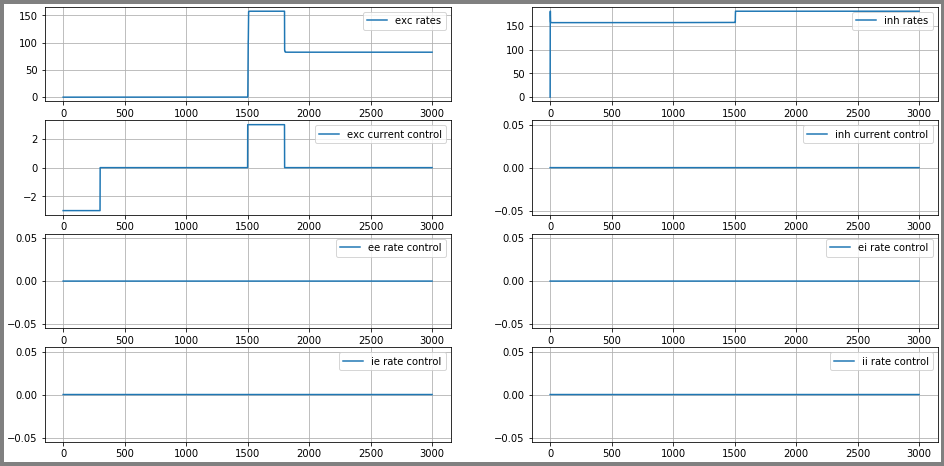

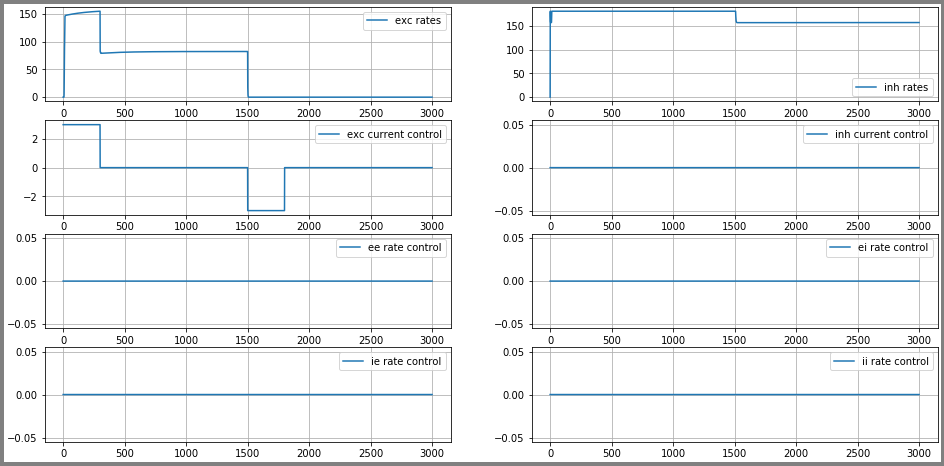

-------  5 3.4000000000000004 3.3000000000000003


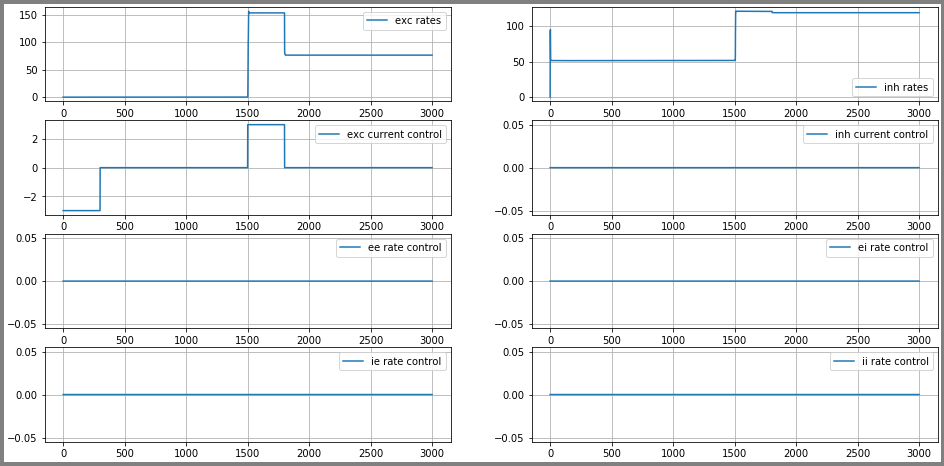

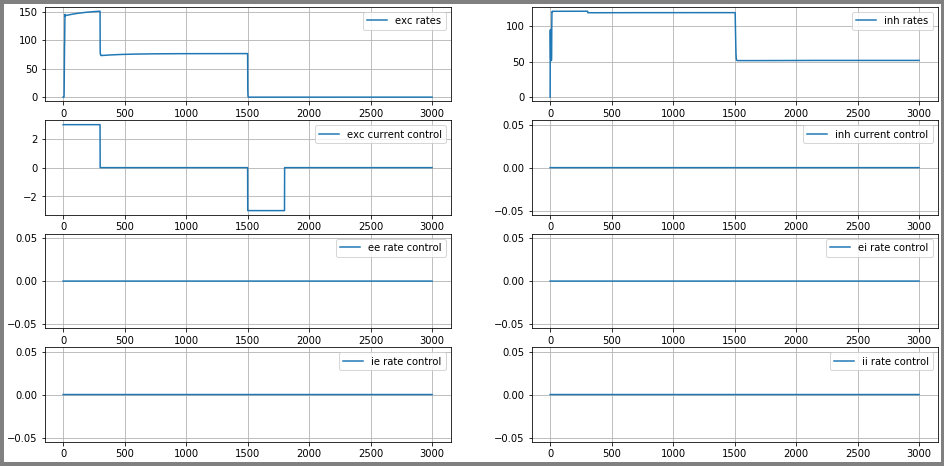

-------  10 3.15 2.6


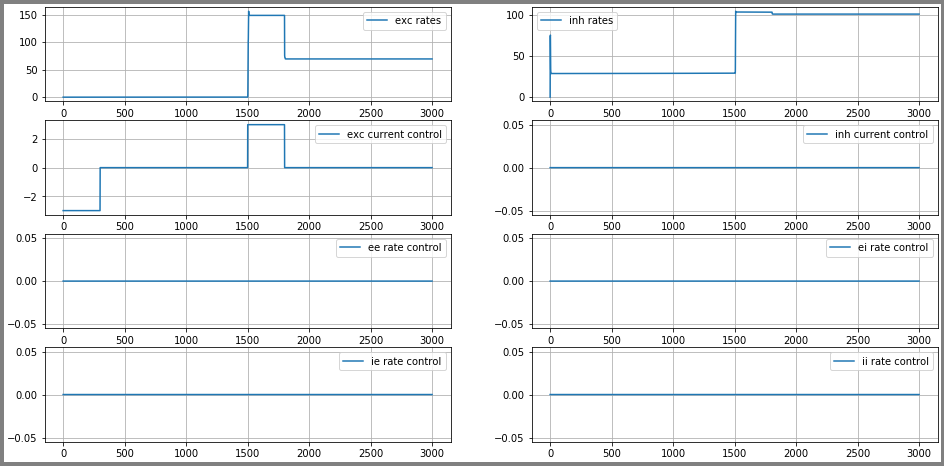

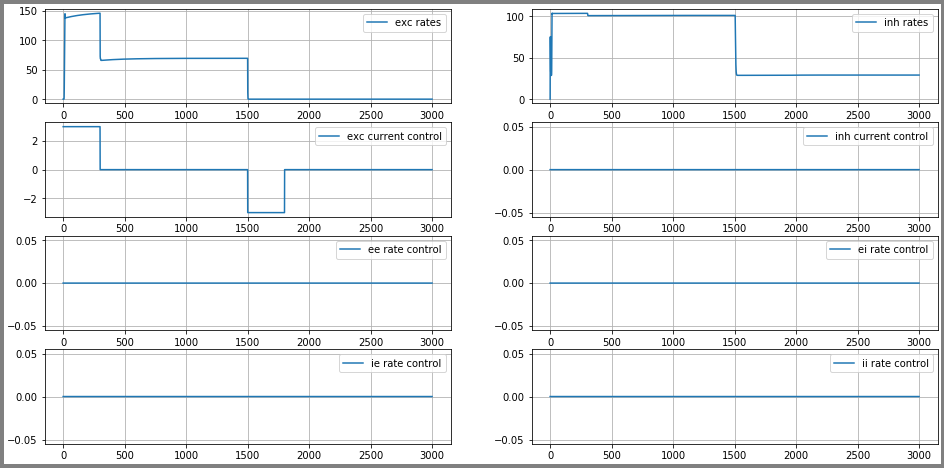

-------  11 3.1 2.5


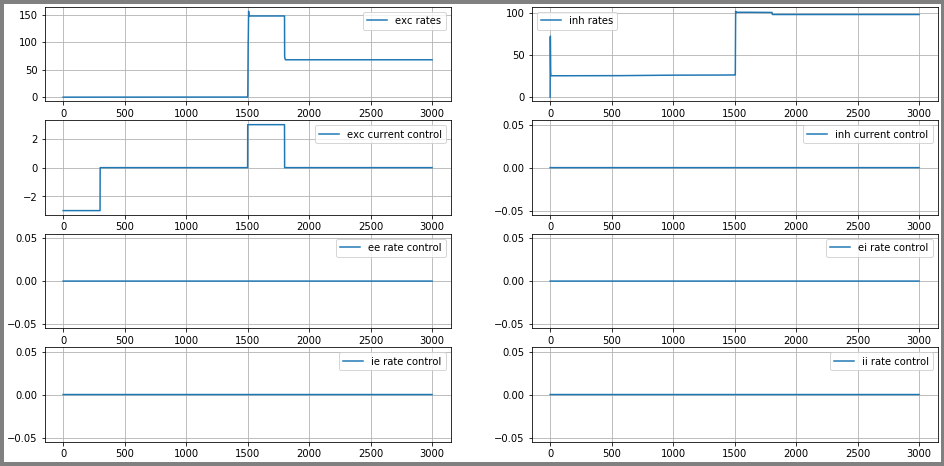

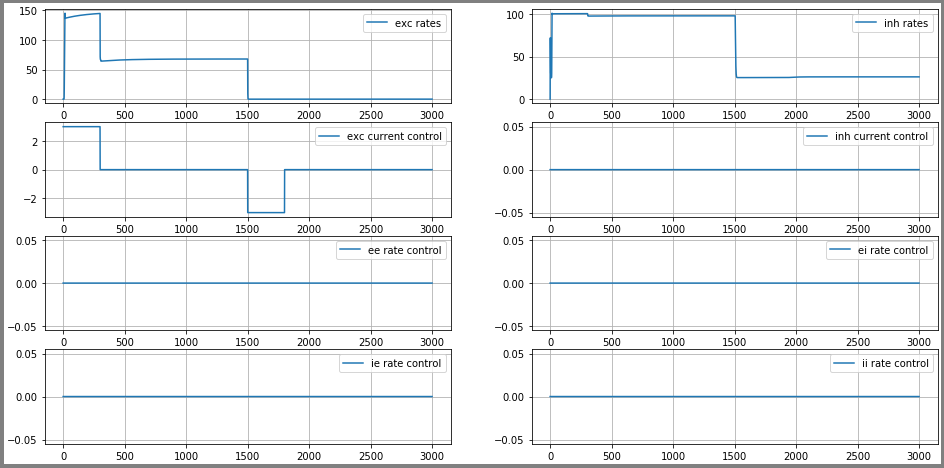

-------  12 3.05 2.45


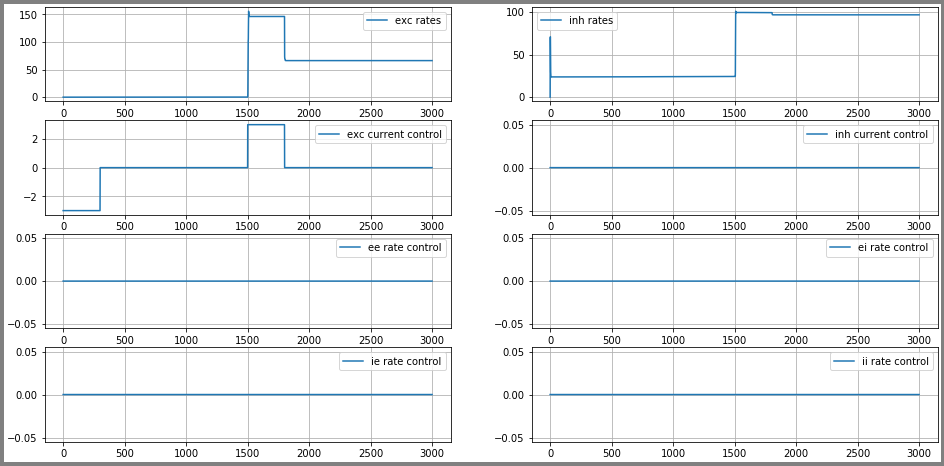

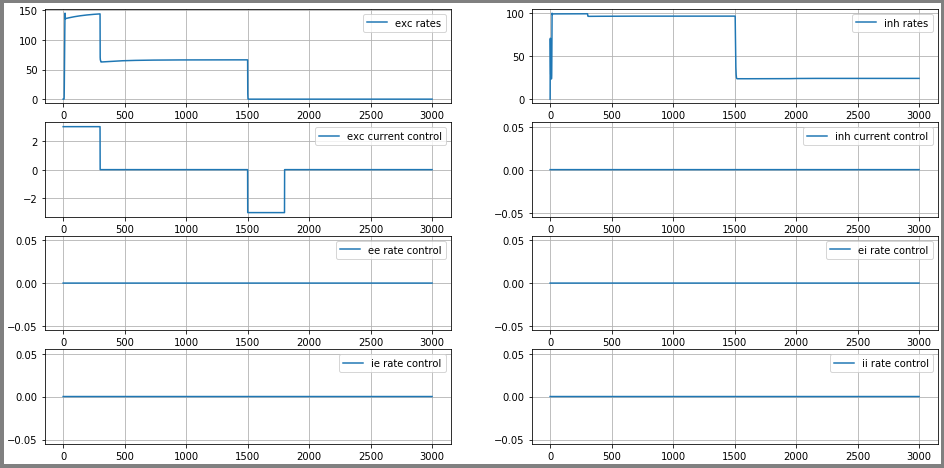

-------  13 3.0 2.4


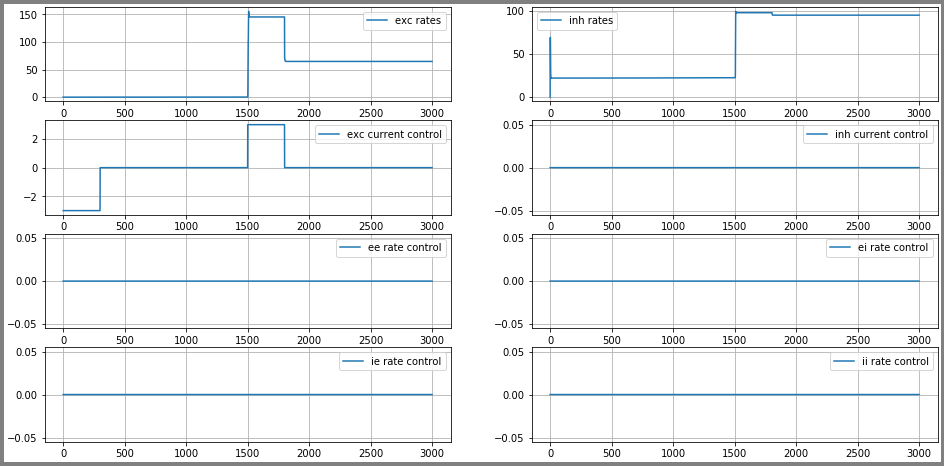

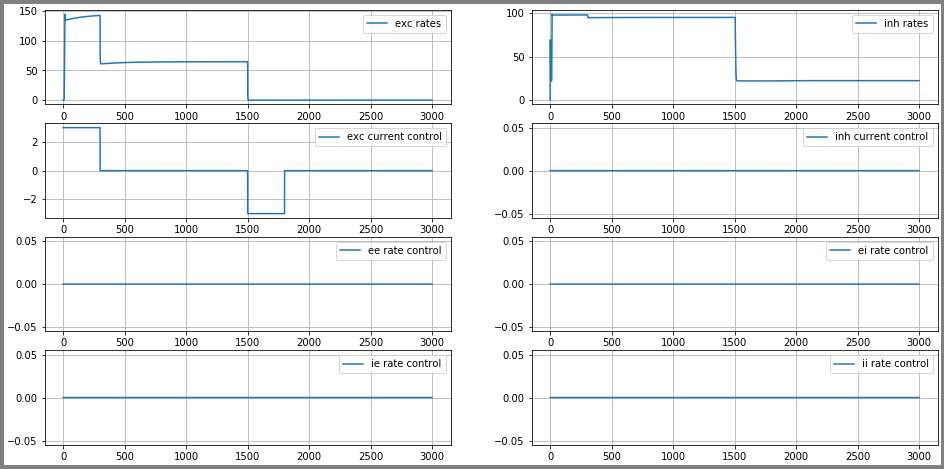

-------  14 2.9499999999999997 2.3499999999999996


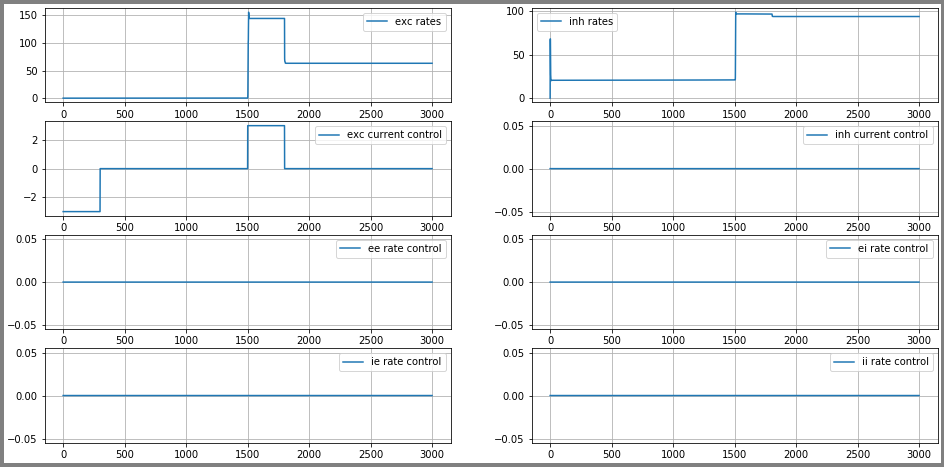

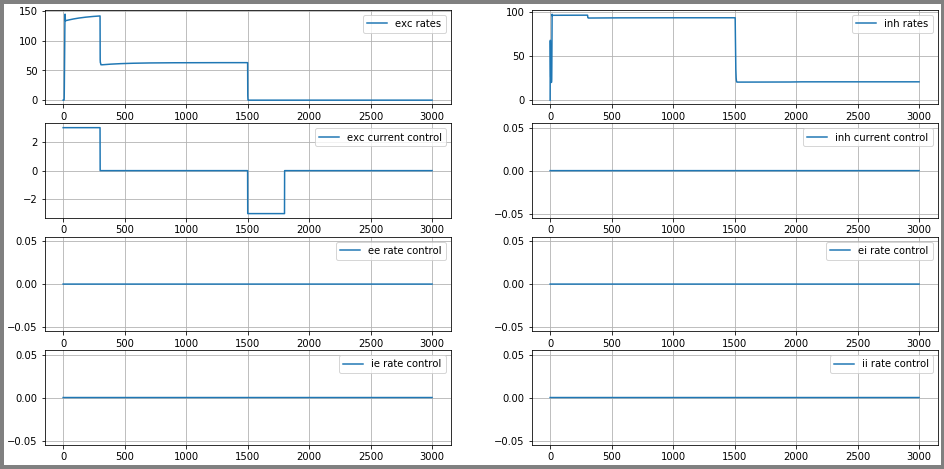

-------  15 2.9 2.25


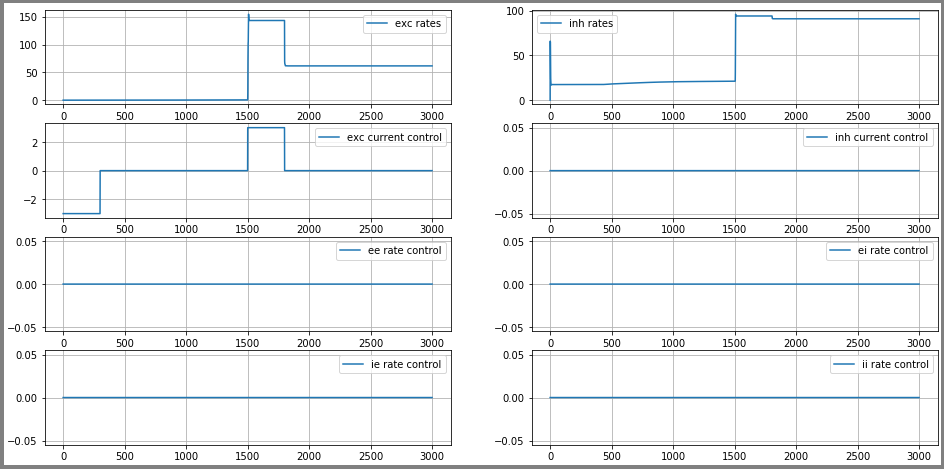

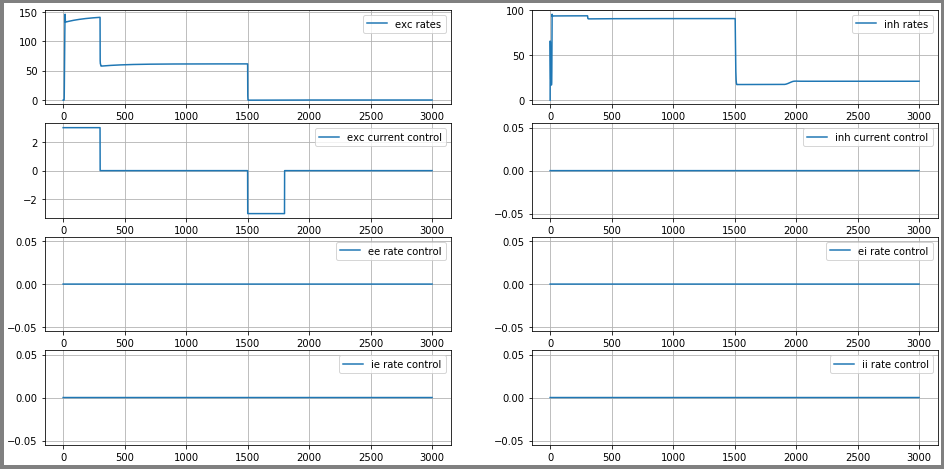

-------  16 2.8499999999999996 2.2


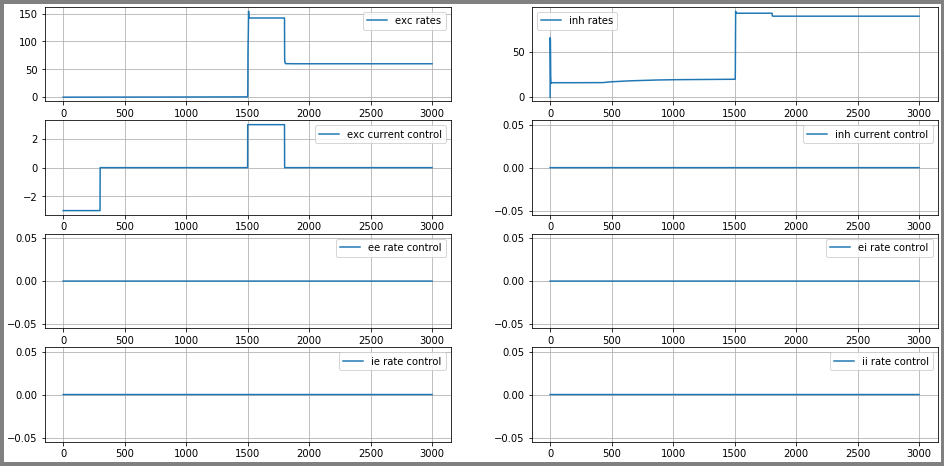

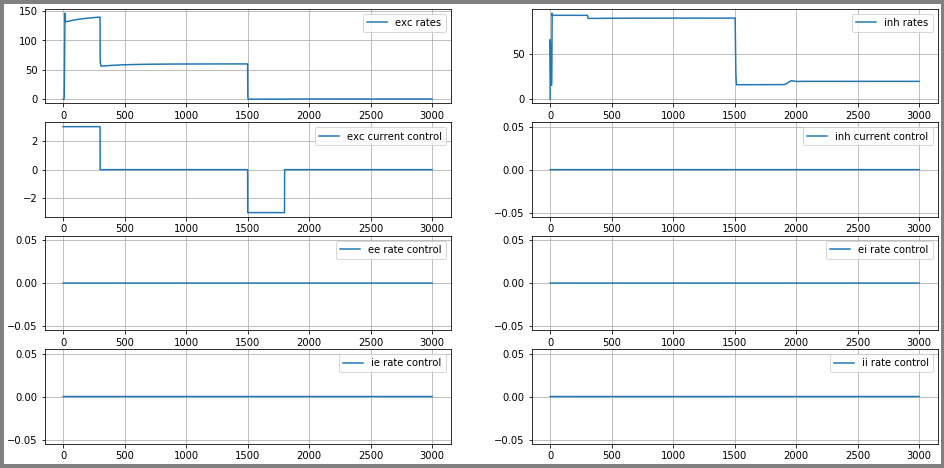

-------  48 2.05 2.45


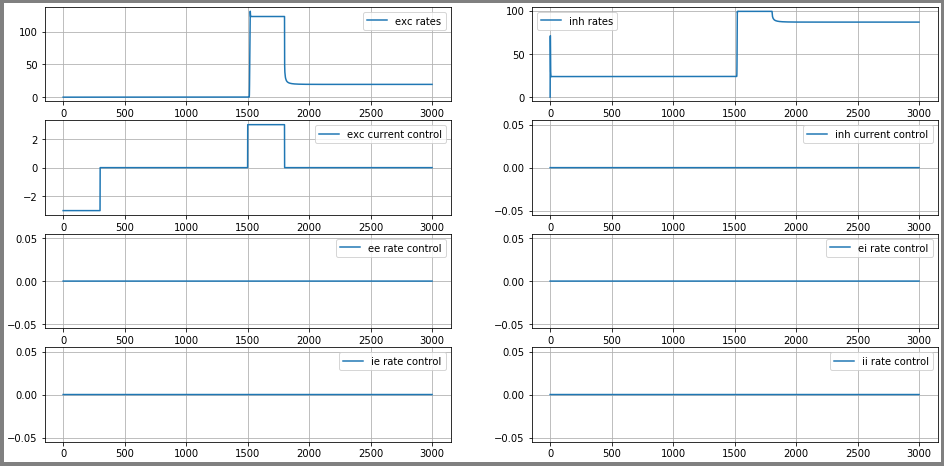

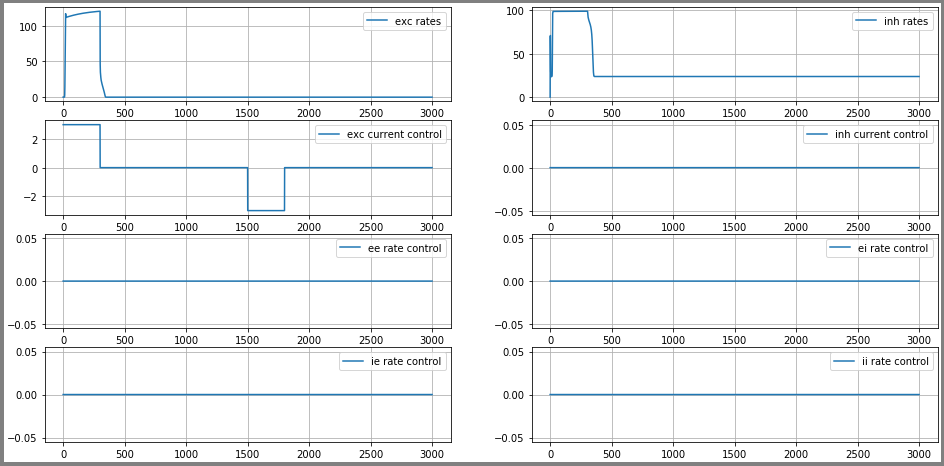

-------  49 2.1 2.5


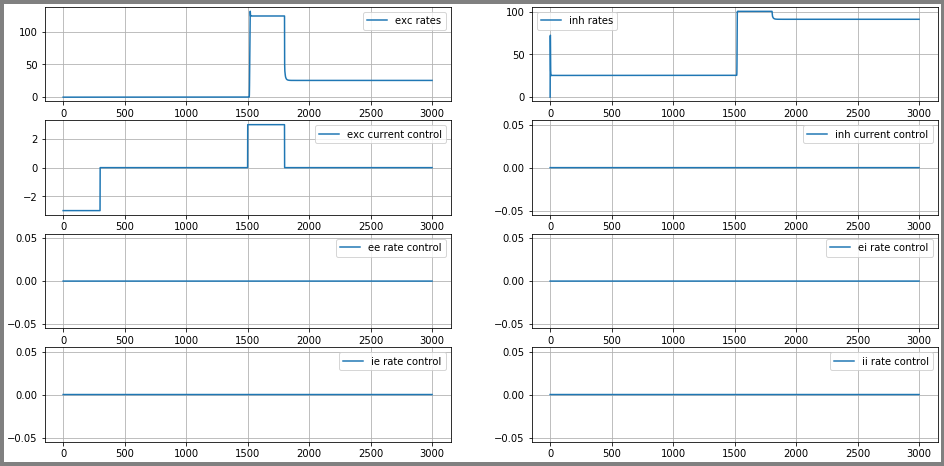

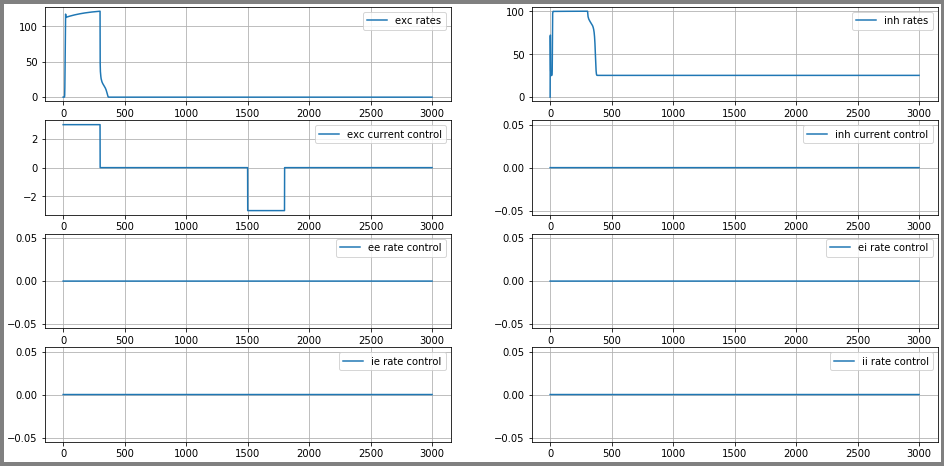

-------  50 2.1 2.55


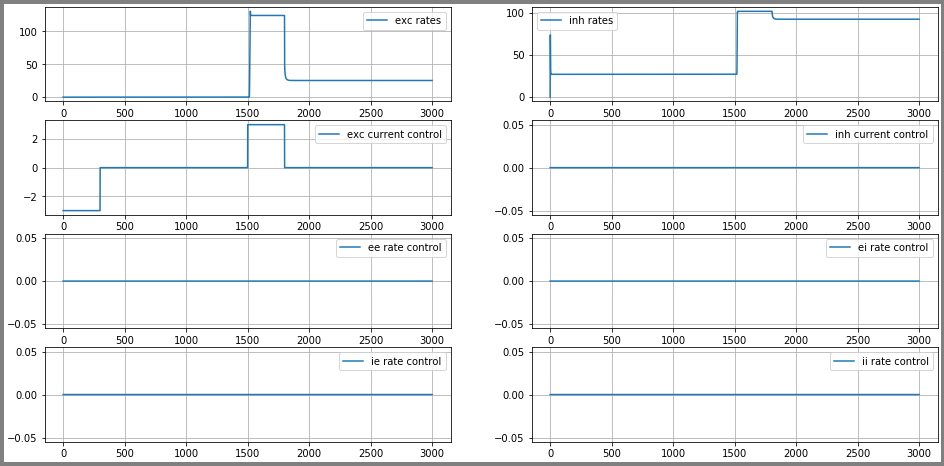

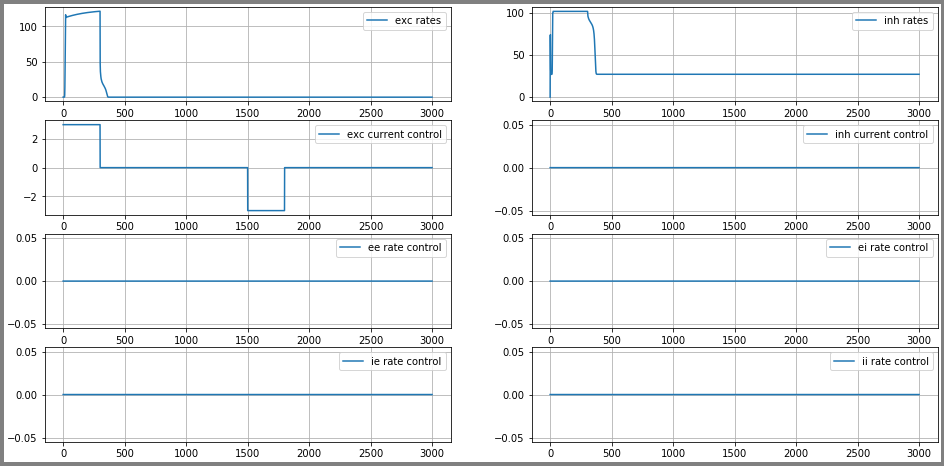

-------  51 2.1 2.6


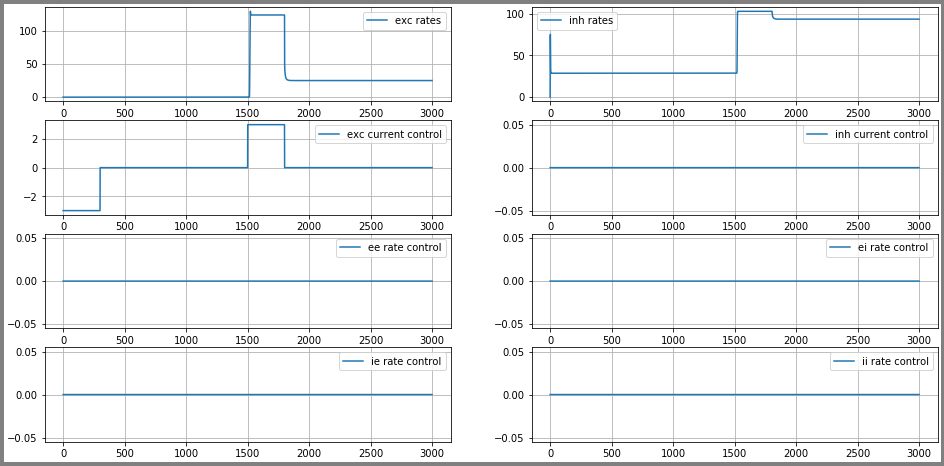

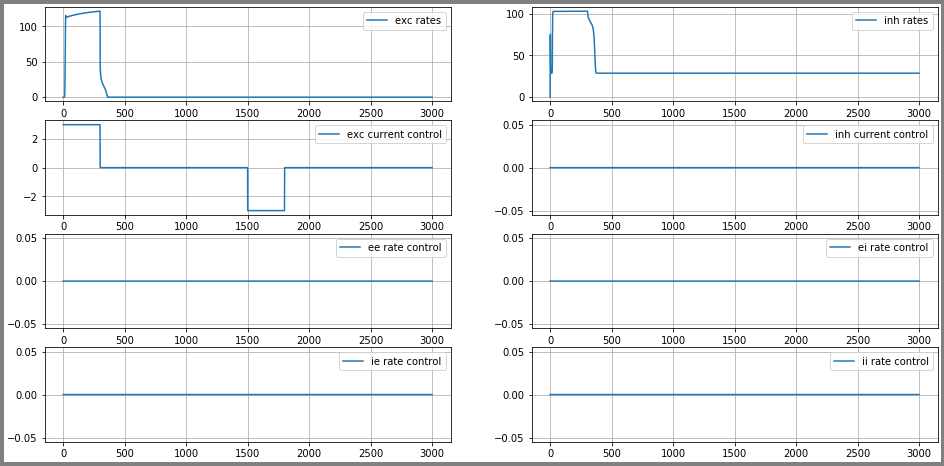

-------  52 2.1 2.75


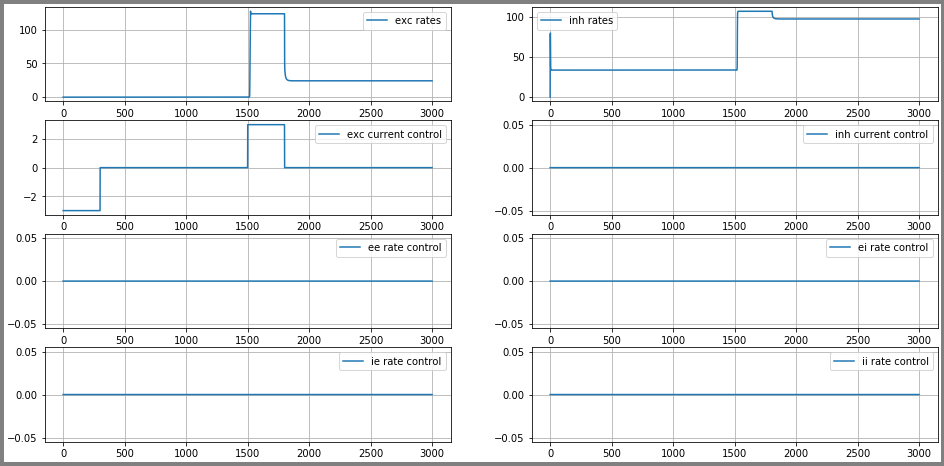

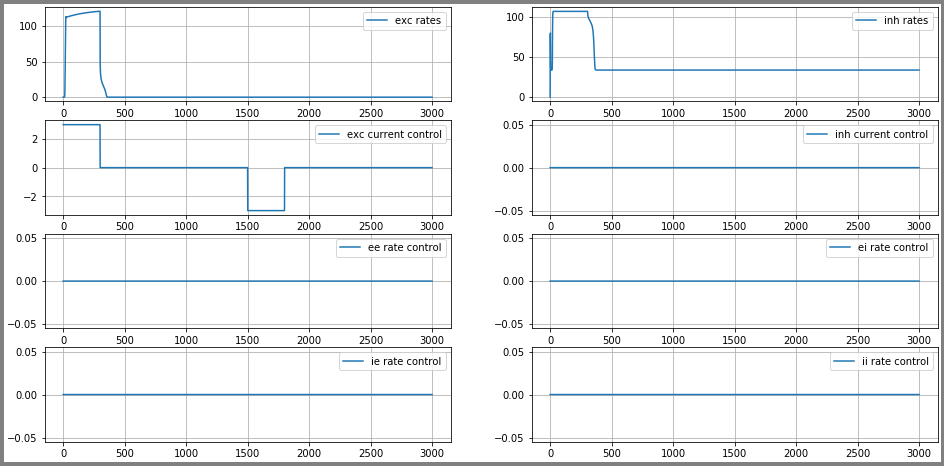

-------  53 2.1 3.0


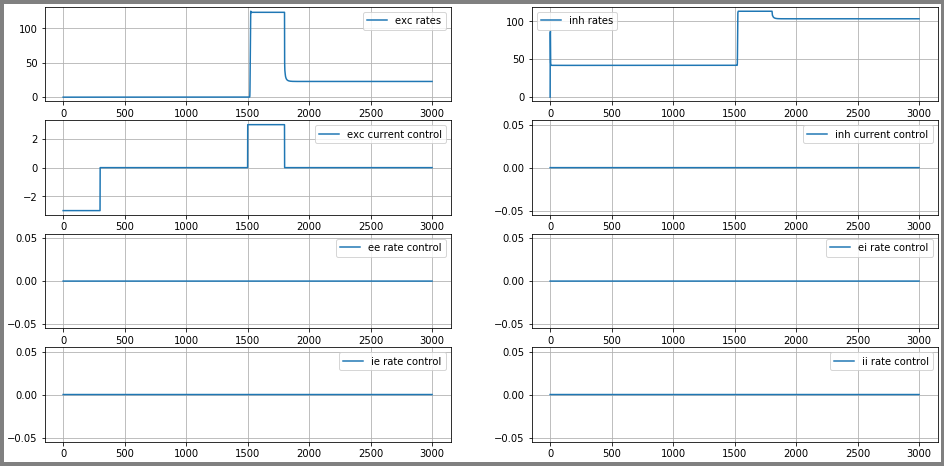

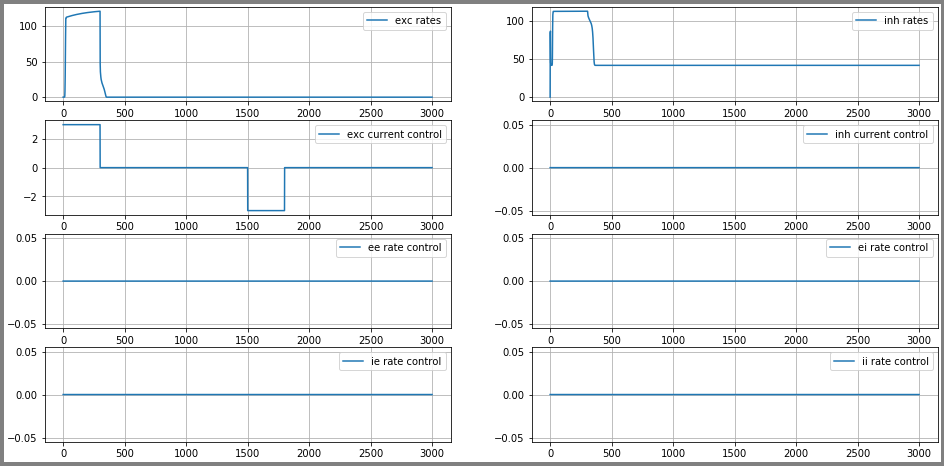

-------  54 2.1 3.25


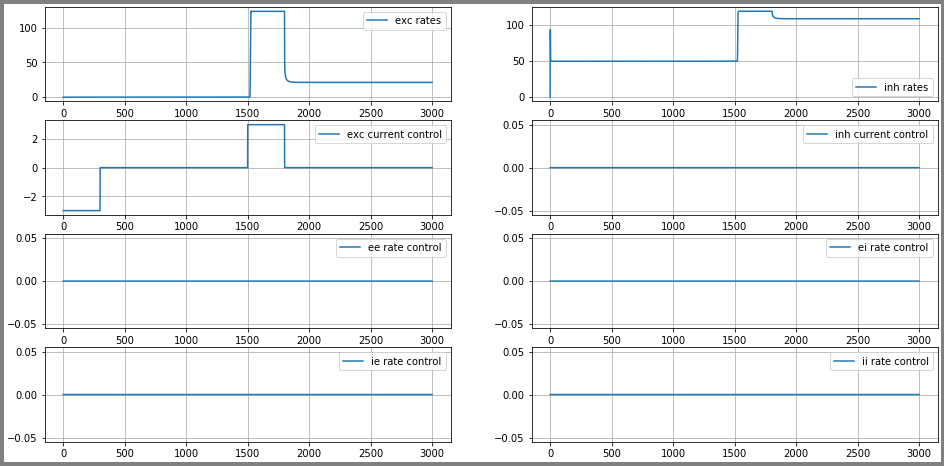

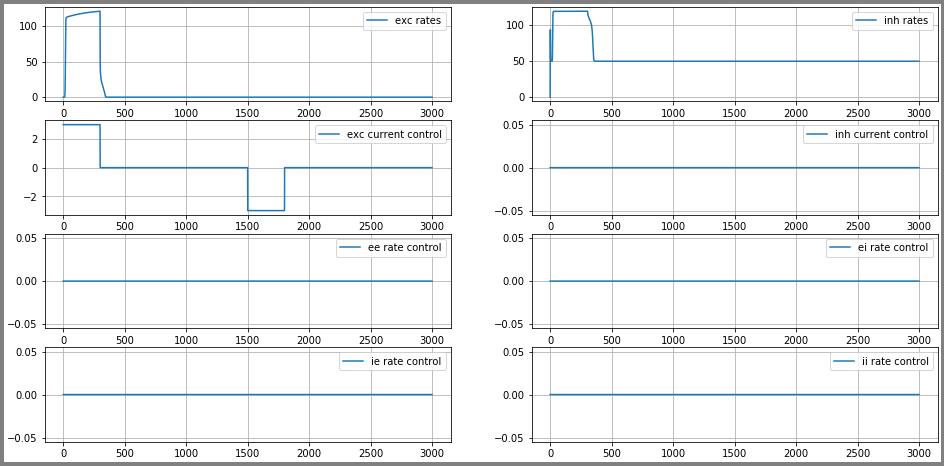

-------  55 2.1 3.4000000000000004


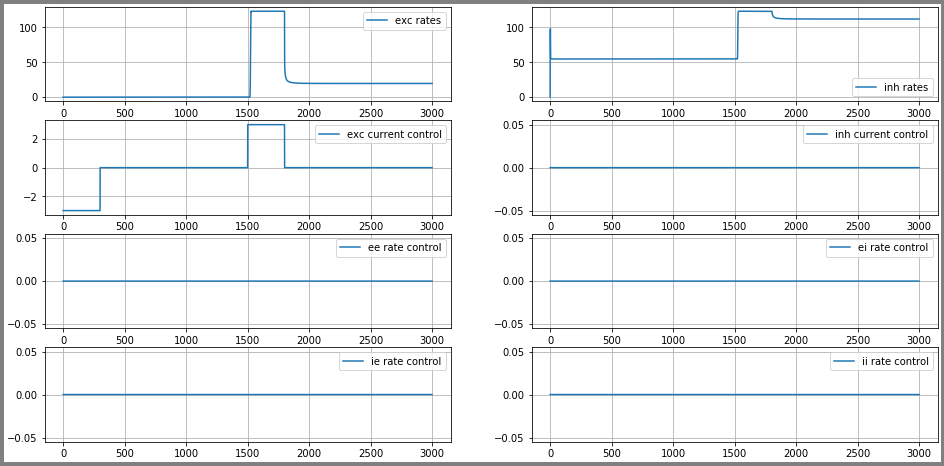

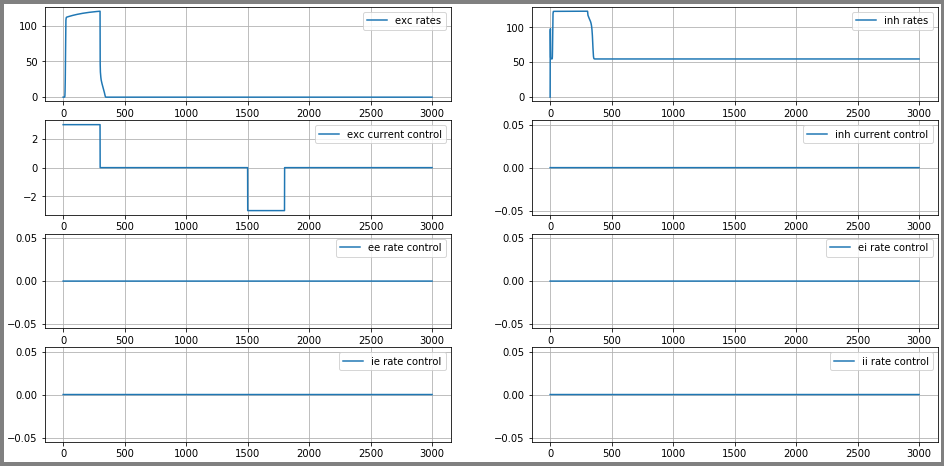

-------  60 2.15 4.5


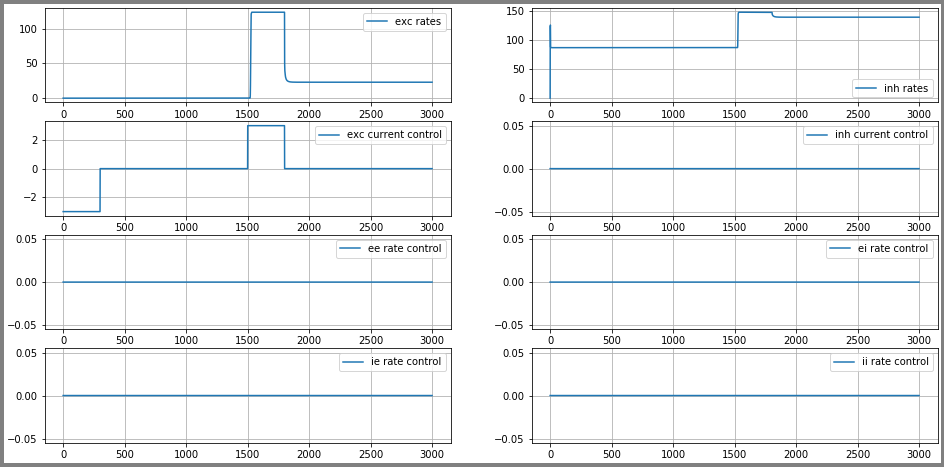

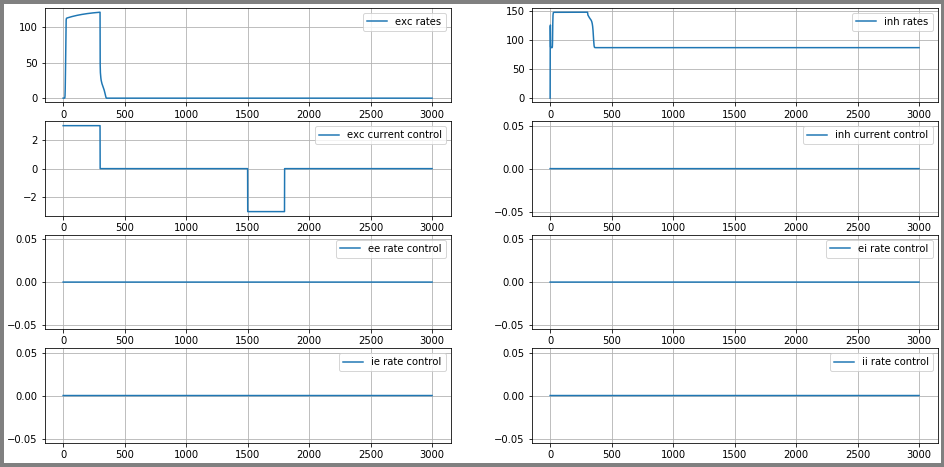

-------  65 2.2 5.4


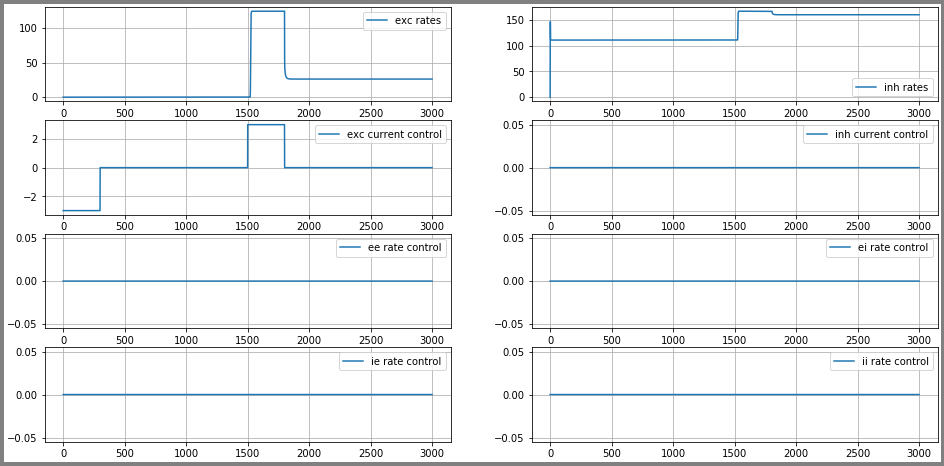

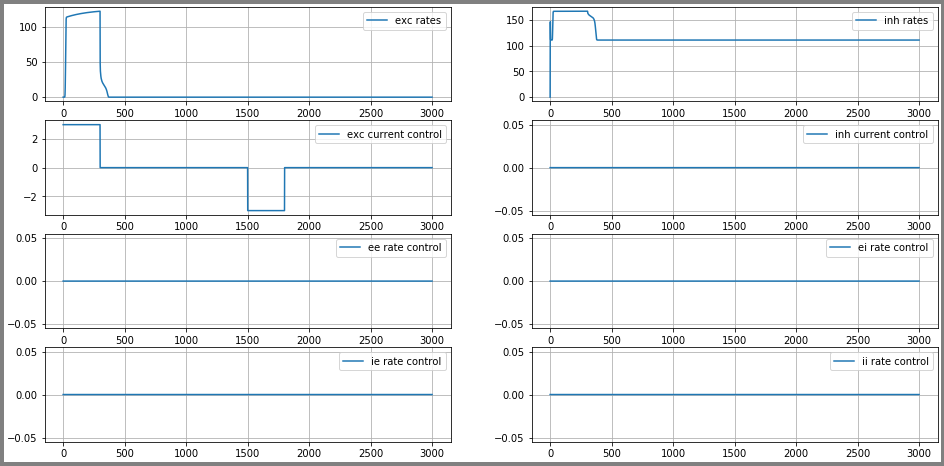

In [137]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

for i in exc_:
    print("------- ", i, ext_exc[i], ext_inh[i])
    aln.params.ext_exc_current = ext_exc[i]
    aln.params.ext_inh_current = ext_inh[i]
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = step_control(maxI_ = 3.)

    plotFunc.plot_traces(aln, control0)
    
    steady_rates = np.zeros((2, 2))
    steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
    steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
    
    control0 = step_control(maxI_ = -3.)
    plotFunc.plot_traces(aln, control0, path_=path, filename_="bistability")

    low_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            low_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            low_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = low_state_vars
    
    aln.params.duration = dur
    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = steady_rates[0,0]
    target[i][:,1,:] = steady_rates[0,1]
    

3.65 3.65 7.4 7.4
0
3.4000000000000004 3.65 3.3000000000000003 7.4
3.4000000000000004 3.4000000000000004 3.3000000000000003 3.3000000000000003
5
3.15 3.65 2.6 7.4
3.15 3.4000000000000004 2.6 3.3000000000000003
3.15 3.15 2.6 2.6
10
3.1 3.65 2.5 7.4
3.1 3.4000000000000004 2.5 3.3000000000000003
3.1 3.15 2.5 2.6
3.1 3.1 2.5 2.5
11
3.05 3.65 2.45 7.4
3.05 3.4000000000000004 2.45 3.3000000000000003
3.05 3.15 2.45 2.6
3.05 3.1 2.45 2.5
3.05 3.05 2.45 2.45
12
3.0 3.65 2.4 7.4
3.0 3.4000000000000004 2.4 3.3000000000000003
3.0 3.15 2.4 2.6
3.0 3.1 2.4 2.5
3.0 3.05 2.4 2.45
3.0 3.0 2.4 2.4
13
2.9499999999999997 3.65 2.3499999999999996 7.4
2.9499999999999997 3.4000000000000004 2.3499999999999996 3.3000000000000003
2.9499999999999997 3.15 2.3499999999999996 2.6
2.9499999999999997 3.1 2.3499999999999996 2.5
2.9499999999999997 3.05 2.3499999999999996 2.45
2.9499999999999997 3.0 2.3499999999999996 2.4
2.9499999999999997 2.9499999999999997 2.3499999999999996 2.3499999999999996
14
2.9 3.65 2.25 7.4
2.9

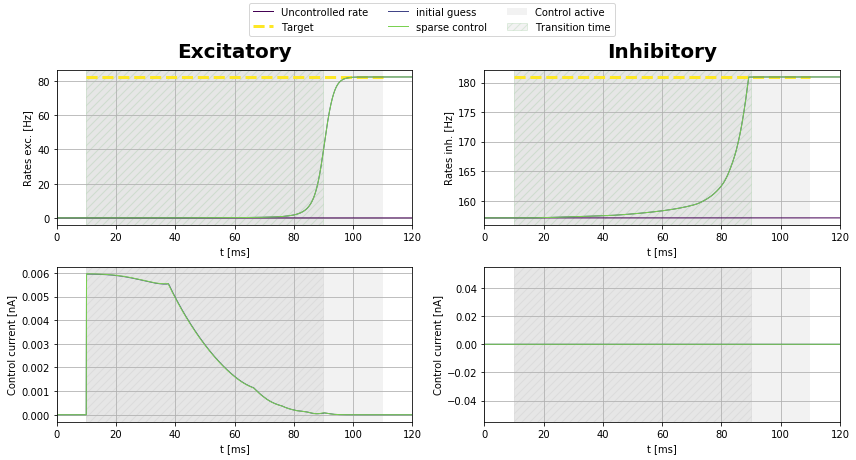

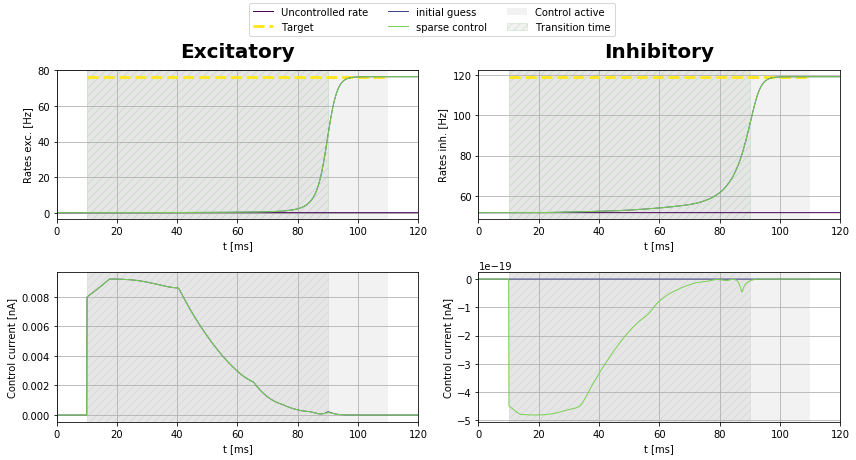

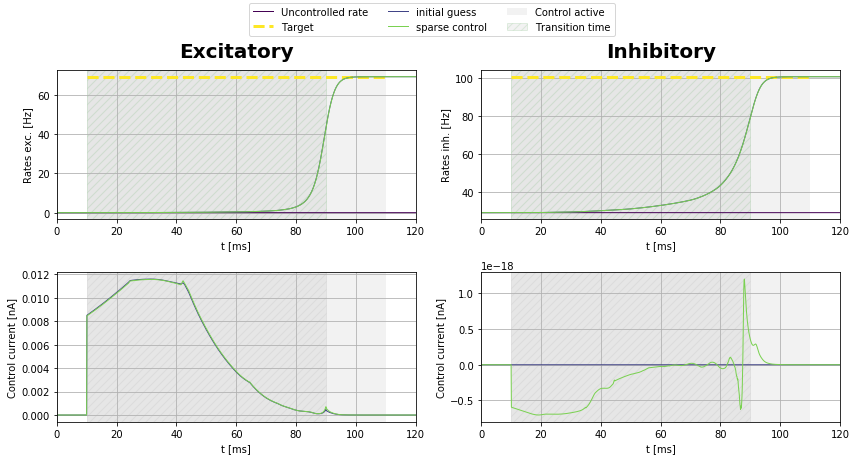

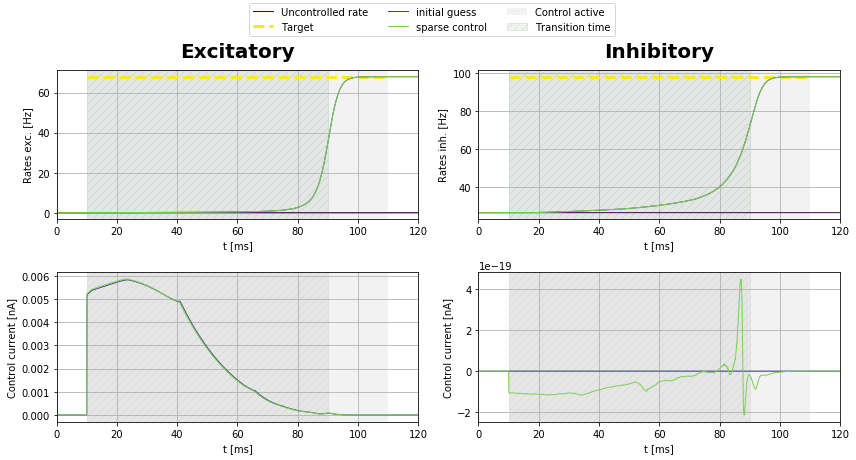

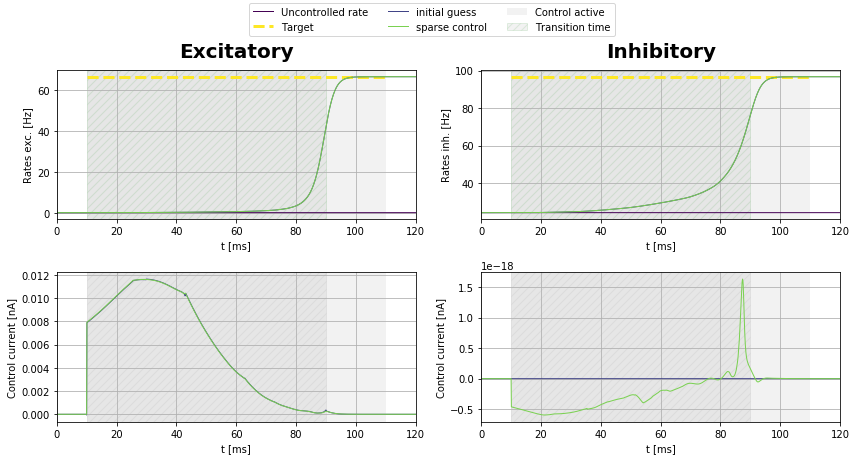

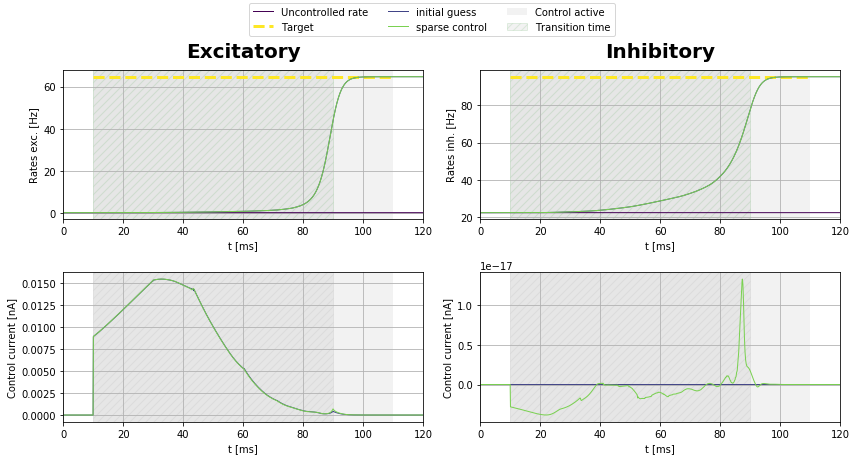

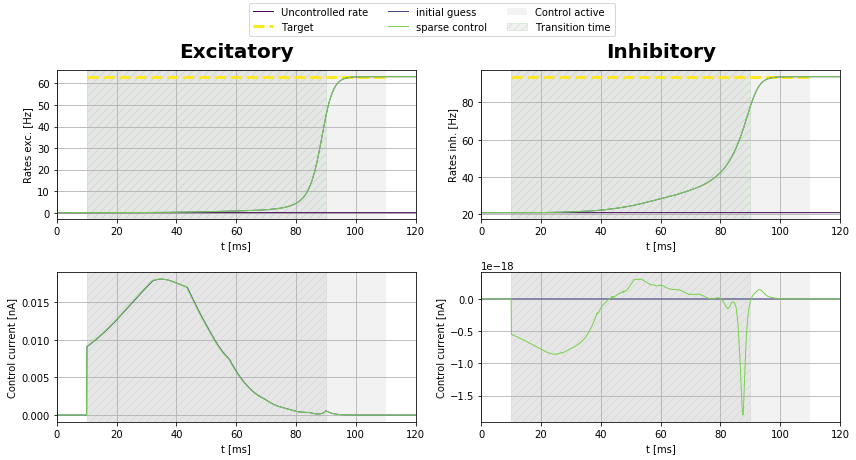

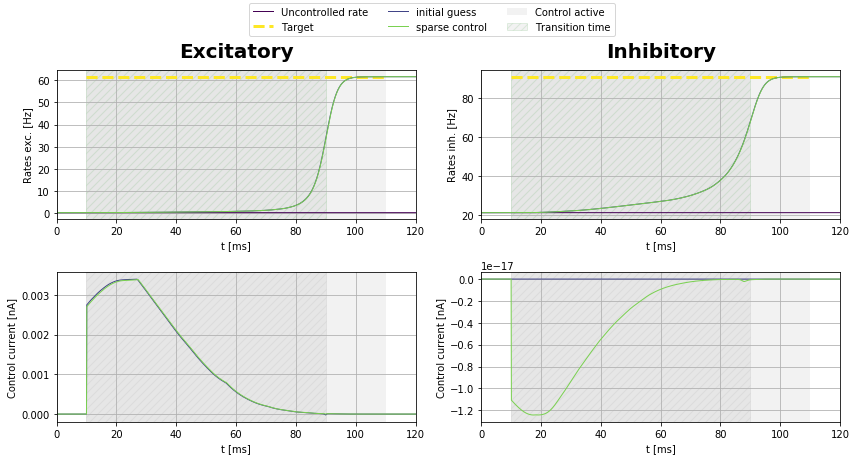

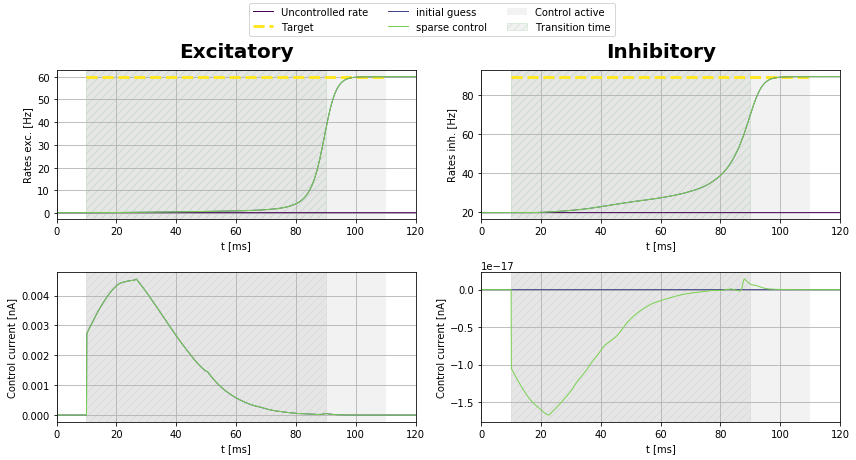

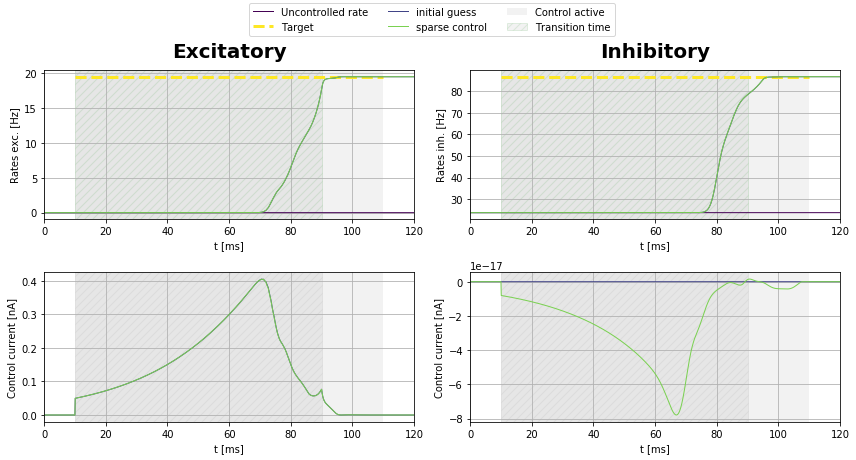

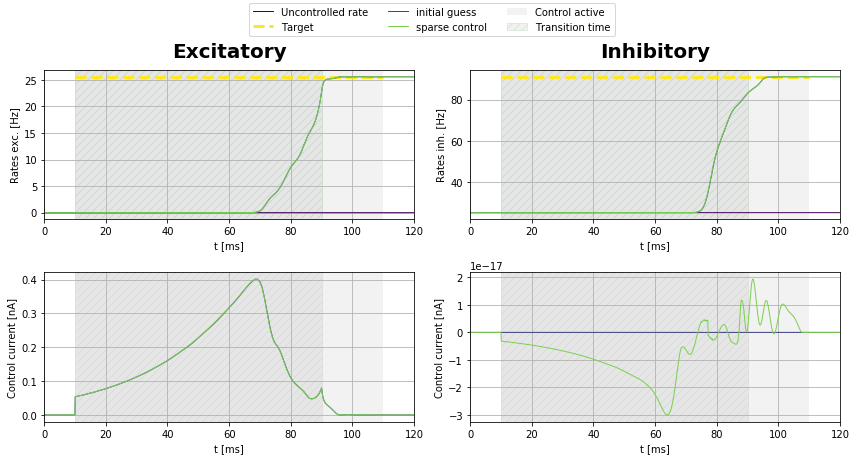

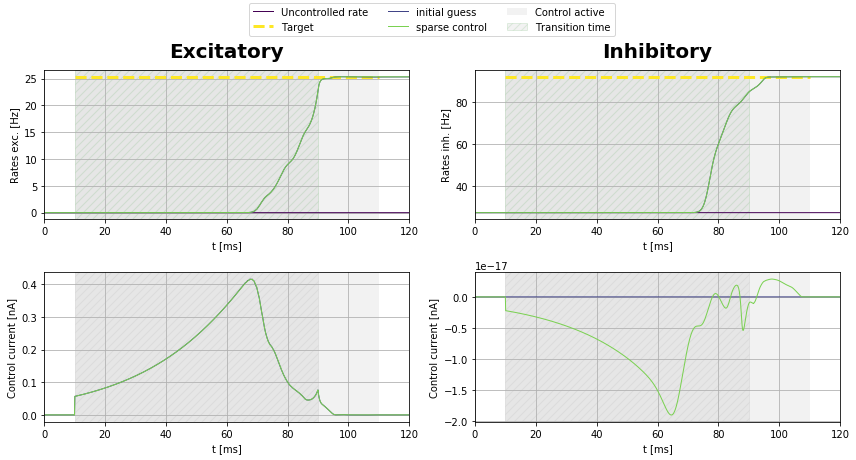

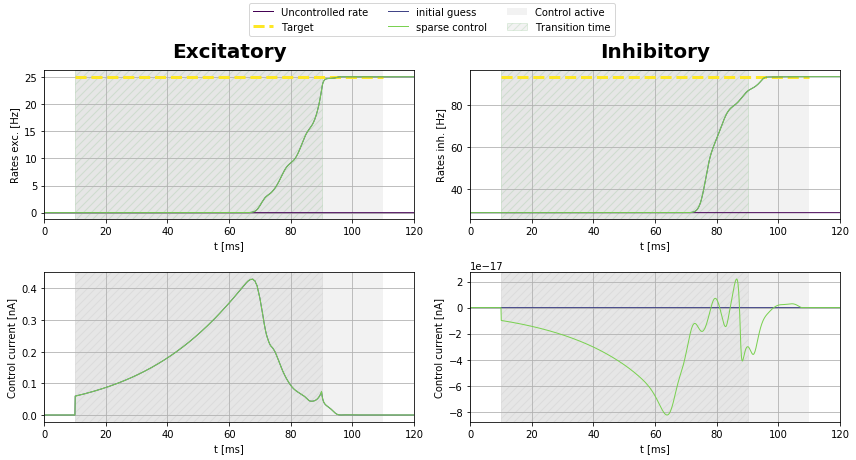

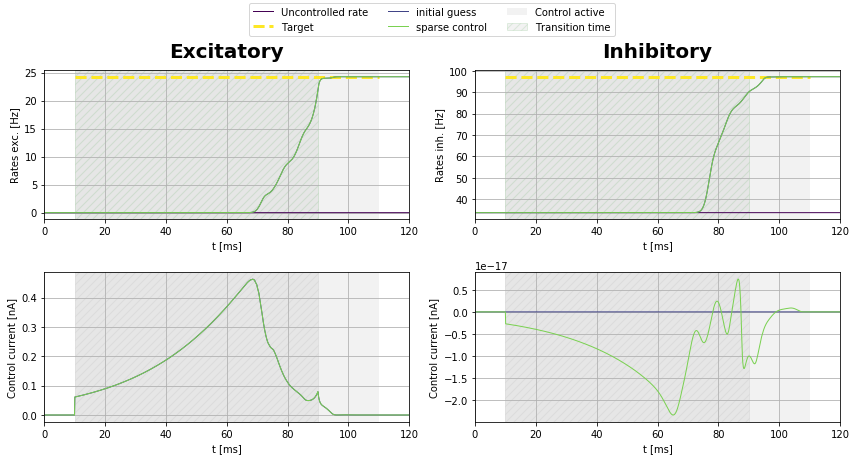

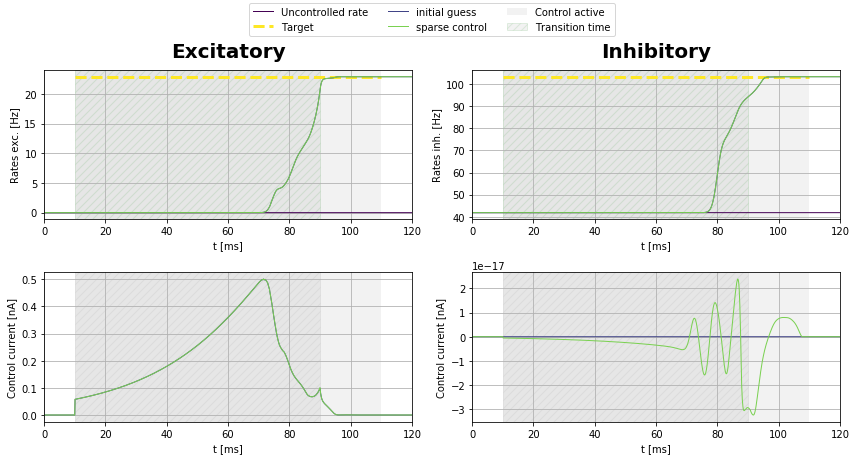

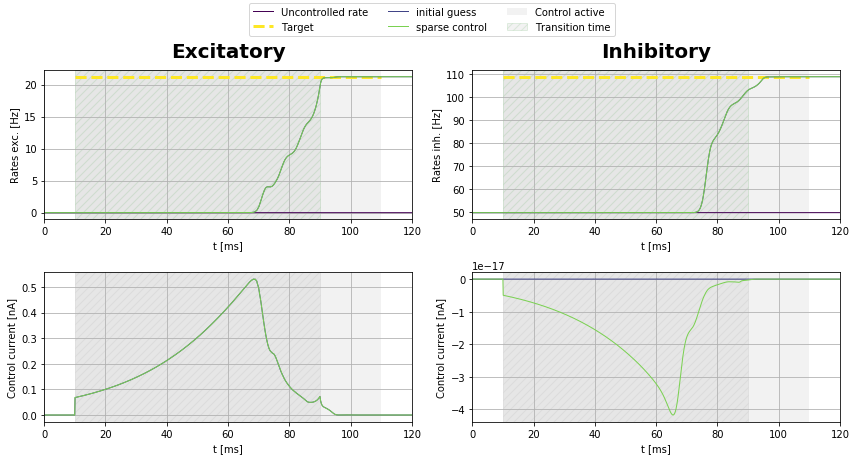

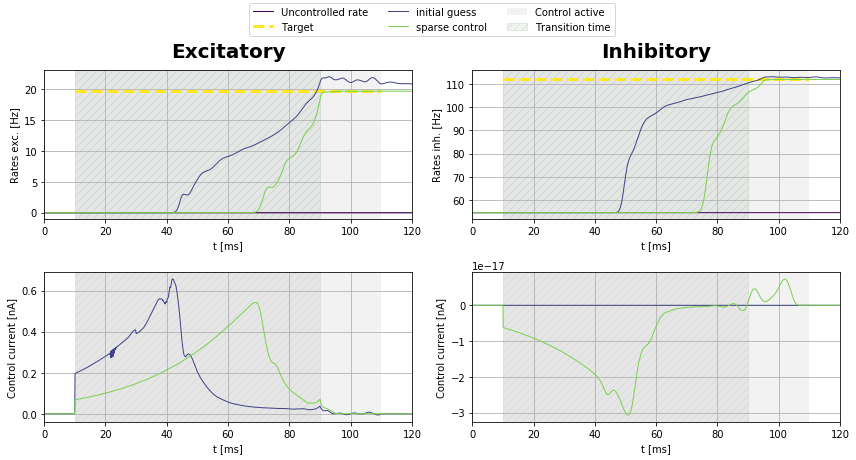

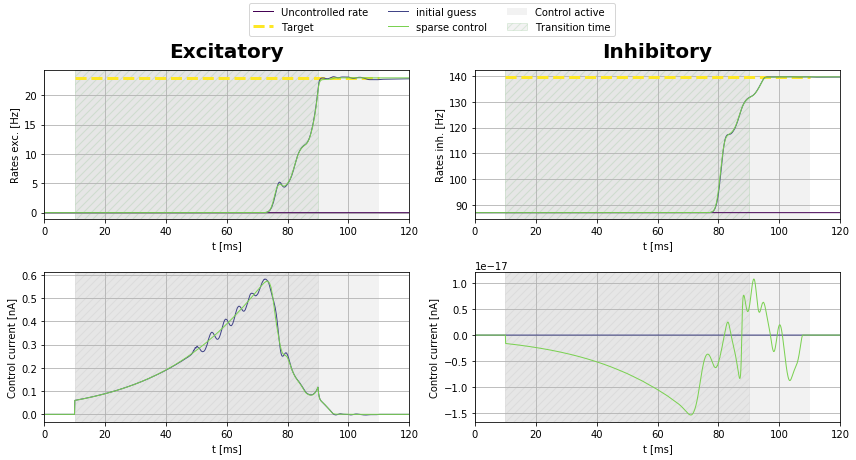

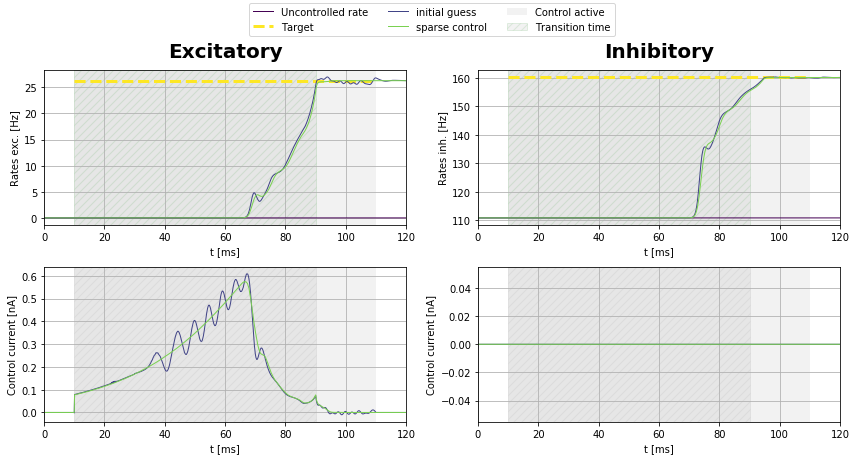

In [138]:
for i in range(len(exc_1)): 
    file_ = "1_" + str(i)
    aln.params.ext_exc_current = exc_1[i]
    aln.params.ext_inh_current = inh_1[i]
    
    for j in range(len(ext_exc)):
        if j in exc_:
            print(exc_1[i],ext_exc[j],inh_1[i],ext_inh[j])
            if exc_1[i] == ext_exc[j] and inh_1[i] ==  ext_inh[j]:
                index_ = j
                print(index_)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars[index_], target[index_], path, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

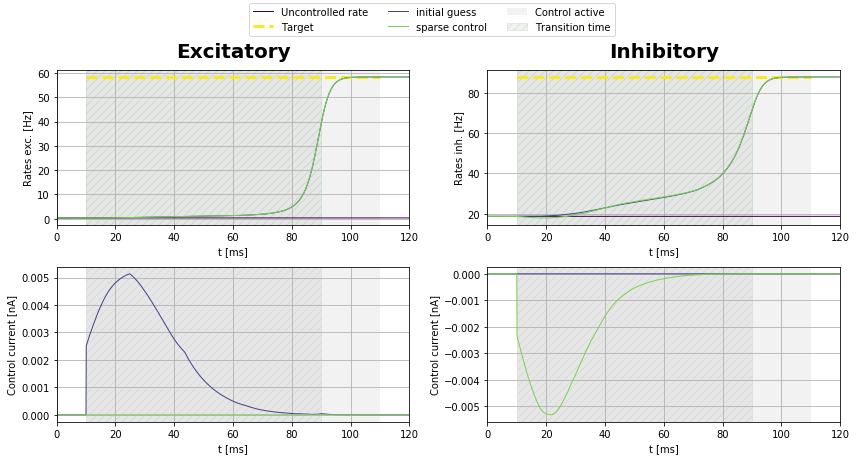

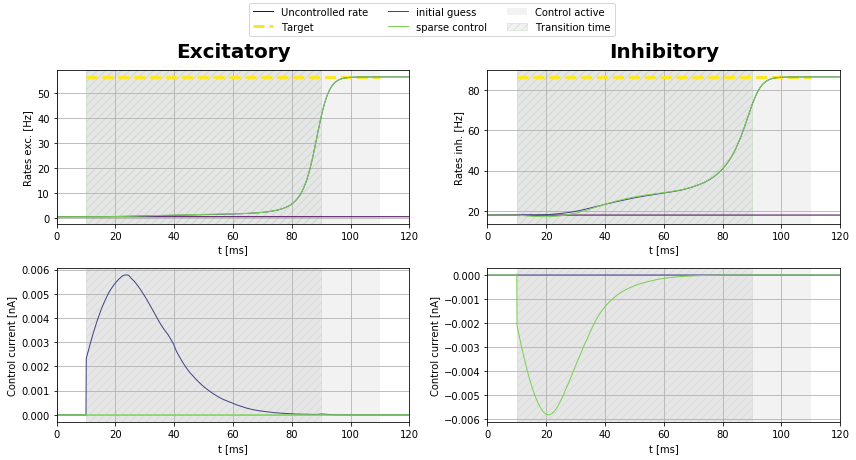

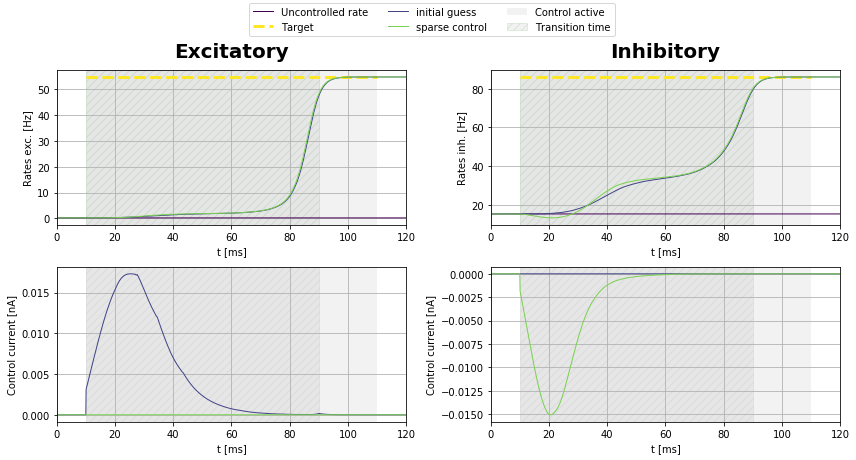

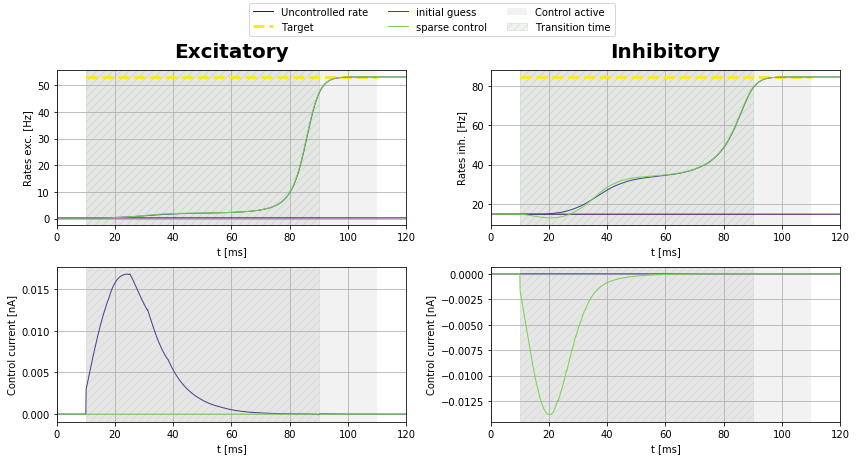

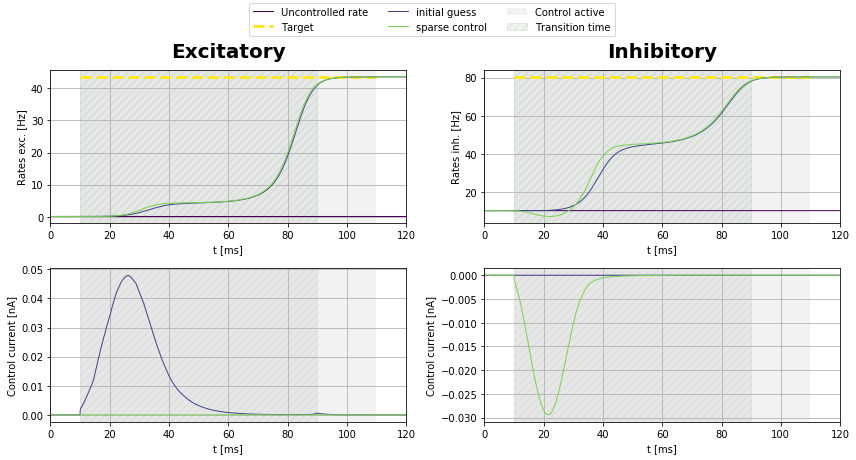

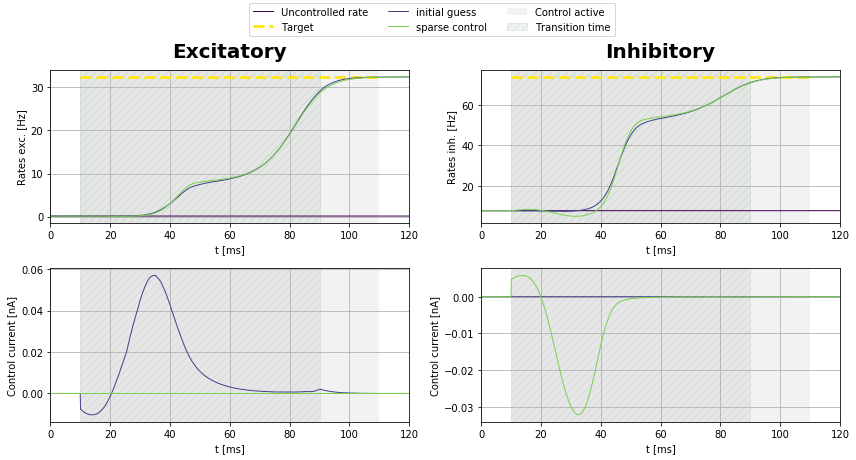

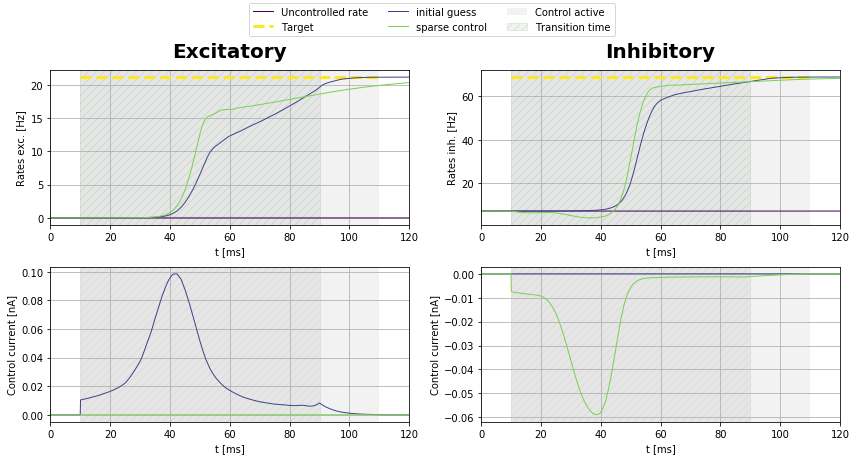

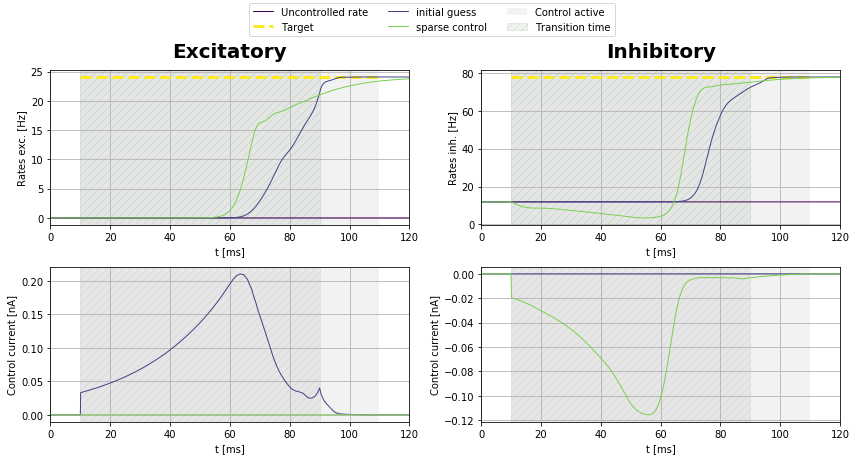

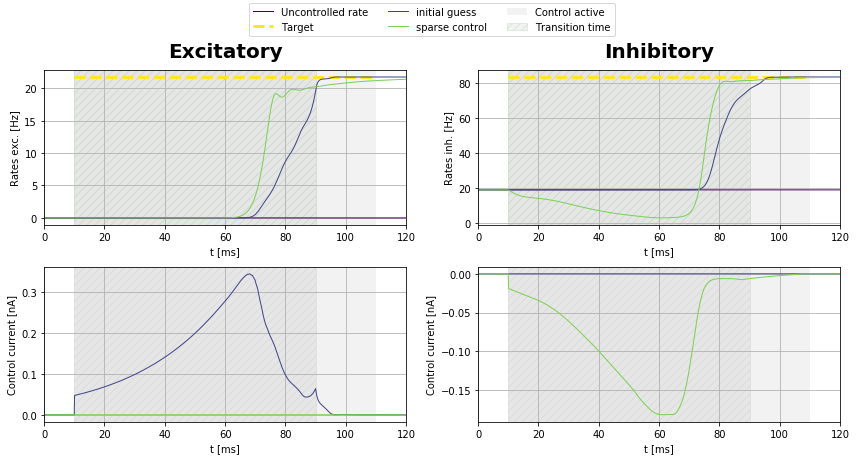

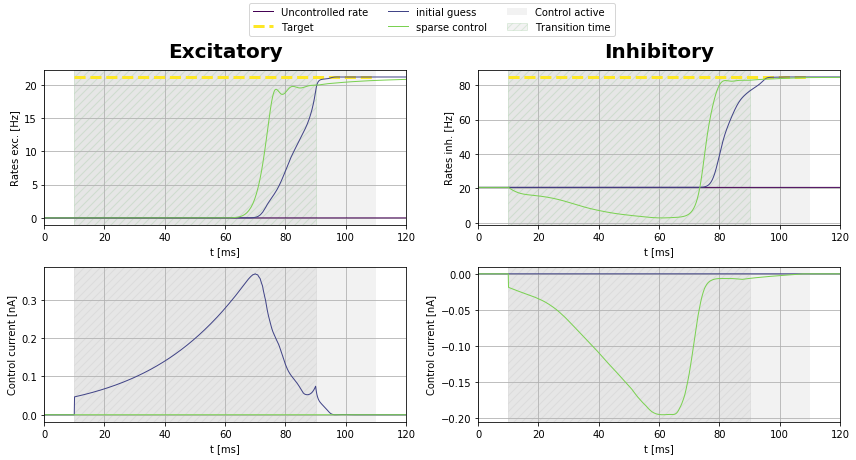

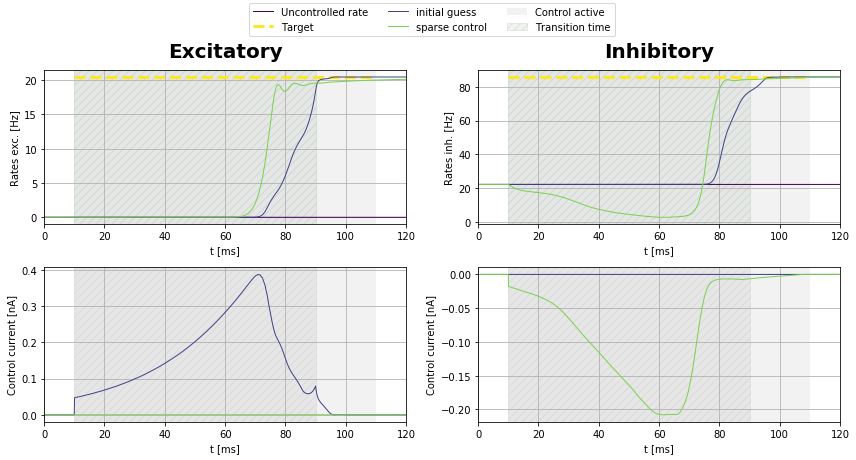

In [139]:
for i in range(len(exc_2)): 
    file_ = "2_" + str(i)
    aln.params.ext_exc_current = exc_2[i]
    aln.params.ext_inh_current = inh_2[i]
    
    for j in range(len(ext_exc)):
        if j in inh_:
            if exc_2[i] == ext_exc[j] and inh_2[i] ==  ext_inh[j]:
                index_ = j
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars[index_], target[index_], path, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)